Đọc dữ liệu

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv('dataset/olist_customers_dataset.csv')
orders = pd.read_csv('dataset/olist_orders_dataset.csv')
items = pd.read_csv('dataset/olist_order_items_dataset.csv')
payments = pd.read_csv('dataset/olist_order_payments_dataset.csv')
reviews = pd.read_csv('dataset/olist_order_reviews_dataset.csv')
products = pd.read_csv('dataset/olist_products_dataset.csv')
sellers = pd.read_csv('dataset/olist_sellers_dataset.csv')
geo = pd.read_csv('dataset/olist_geolocation_dataset.csv')
translation = pd.read_csv('dataset/product_category_name_translation.csv')

Tổng quan dữ liệu

In [83]:
datasets = {
    'customers': customers,
    'orders': orders,
    'items': items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'geo': geo
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("Shape:", df.shape)
    print(df.info())


customers
Shape: (99441, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

orders
Shape: (99441, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 

Missing Values

In [84]:
missing = pd.DataFrame()

for name, df in datasets.items():
    temp = (df.isnull().sum()/len(df))*100
    temp = temp[temp>0]
    
    if len(temp)>0:
        print(f"\n{name}")
        print(temp.sort_values(ascending=False))


orders
order_delivered_customer_date    2.981668
order_delivered_carrier_date     1.793023
order_approved_at                0.160899
dtype: float64

reviews
review_comment_title      88.341530
review_comment_message    58.702532
dtype: float64

products
product_category_name         1.851234
product_name_lenght           1.851234
product_description_lenght    1.851234
product_photos_qty            1.851234
product_weight_g              0.006070
product_length_cm             0.006070
product_height_cm             0.006070
product_width_cm              0.006070
dtype: float64


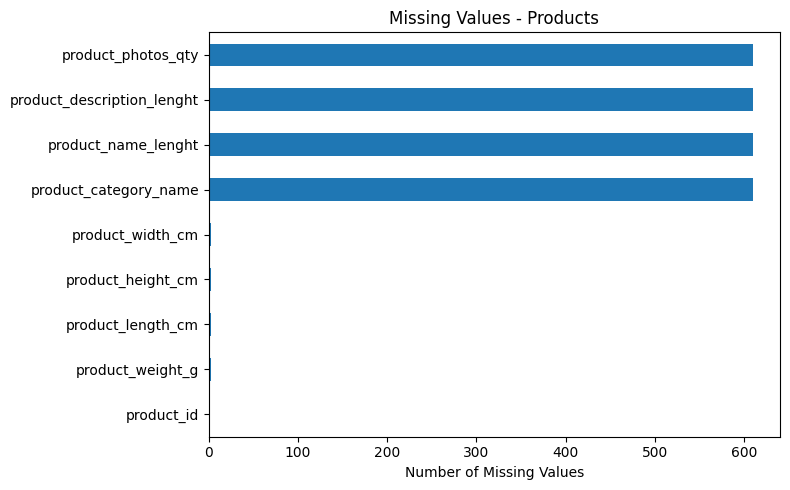

In [85]:
missing = (
    products.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))

missing.sort_values().plot(kind='barh')

plt.title('Missing Values - Products')
plt.xlabel('Number of Missing Values')

plt.tight_layout()
plt.show()

Duplicate Records

In [86]:
for name, df in datasets.items():
    print(
        name,
        df.duplicated().sum()
    )

customers 0
orders 0
items 0
payments 0
reviews 0
products 0
sellers 0
geo 261831


Ghép dữ liệu bán hàng

In [87]:
sales = orders.merge(
    items,
    on='order_id'
)

sales = sales.merge(
    payments,
    on='order_id'
)

sales = sales.merge(
    customers,
    on='customer_id'
)

Doanh thu tổng thể

In [88]:
print(
    "Total Revenue:",
    sales['payment_value'].sum()
)

Total Revenue: 20308134.709999997


Doanh thu theo tháng

In [89]:
sales['order_purchase_timestamp'] = pd.to_datetime(
    sales['order_purchase_timestamp']
)

sales['year_month'] = (
    sales['order_purchase_timestamp']
    .dt.to_period('M')
)

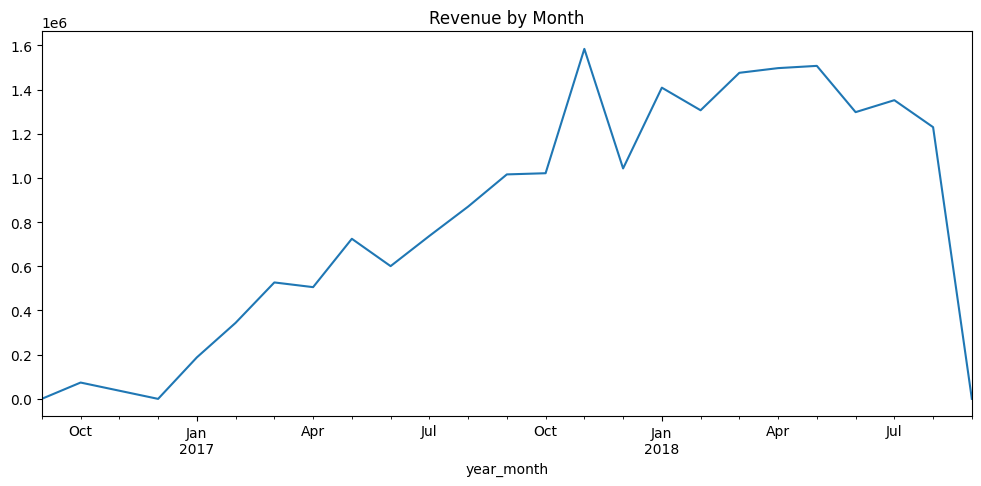

In [90]:
monthly = (
    sales.groupby('year_month')
    ['payment_value']
    .sum()
)

monthly.plot(
    figsize=(12,5)
)

plt.title("Revenue by Month")
plt.show()

Trạng thái đơn hàng

In [91]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

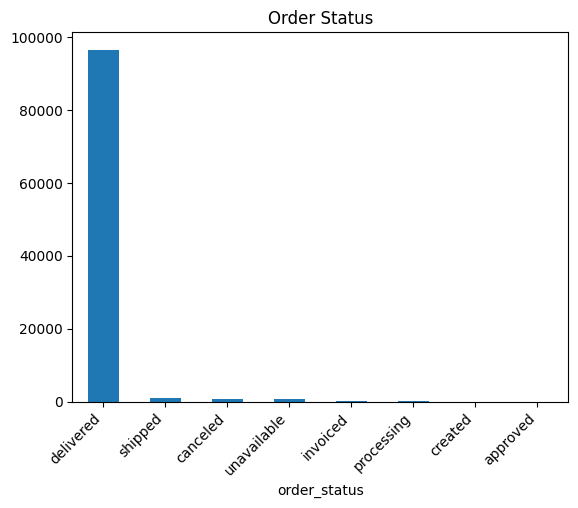

In [92]:
orders['order_status'].value_counts().plot(
    kind='bar'
)

plt.title("Order Status")
plt.xticks(rotation=45, ha='right')
plt.show()

Top 10 Bang có nhiều khách hàng nhất

In [93]:
state_customer = (
    customers['customer_state']
    .value_counts()
    .head(10)
)

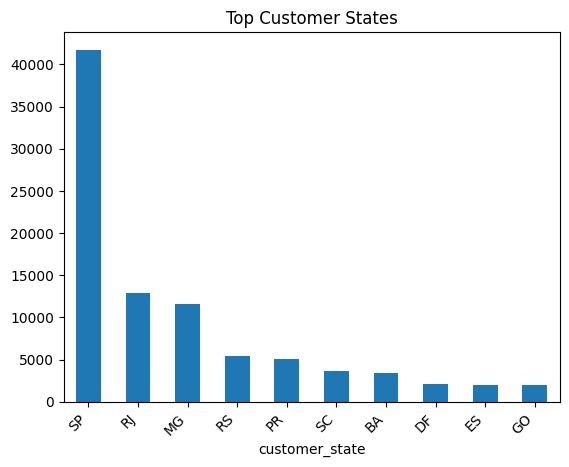

In [94]:
state_customer.plot(
    kind='bar'
)

plt.title(
    "Top Customer States"
)
plt.xticks(rotation=45, ha='right')
plt.show()

Top 10 Seller

In [95]:
top_seller = (
    items.groupby('seller_id')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

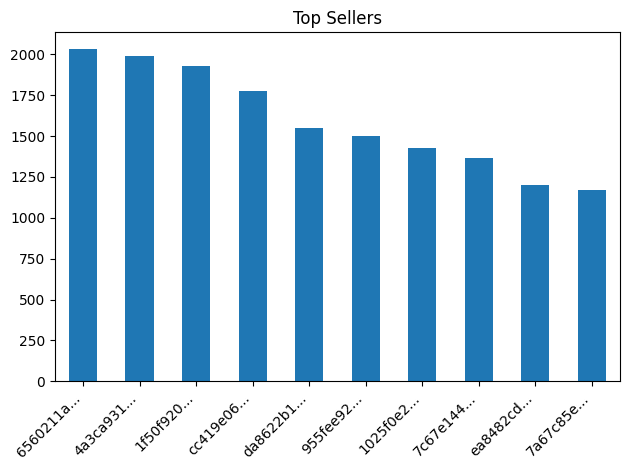

In [96]:
top_seller.index = [
    s[:8] + "..." for s in top_seller.index
]

top_seller.plot(kind='bar')

plt.title('Top Sellers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top Product Categories
(Ghép với bảng translation)

In [97]:
products = products.merge(
    translation,
    on='product_category_name',
    how='left'
)

In [98]:
product_sales = items.merge(
    products,
    on='product_id'
)

In [99]:
top_cat = (
    product_sales[
        'product_category_name_english'
    ]
    .value_counts()
    .head(10)
)

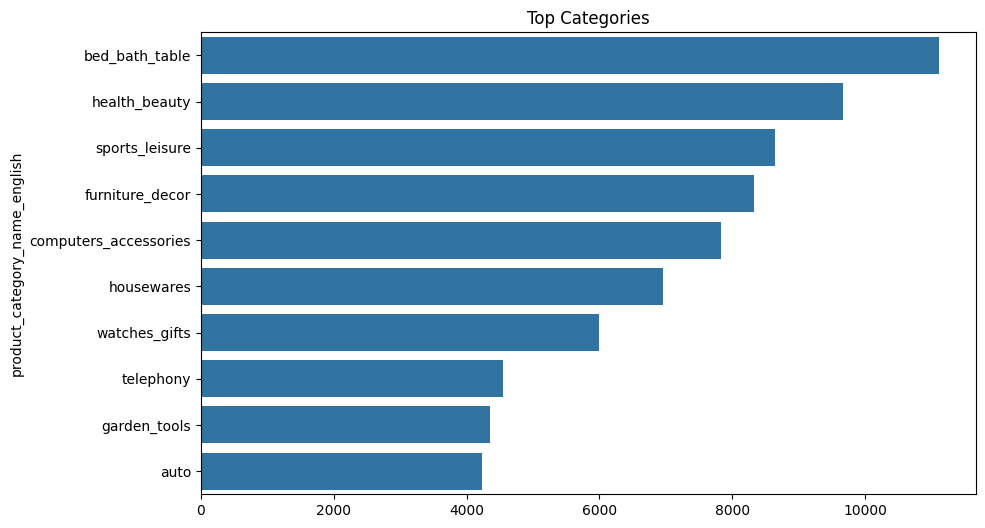

In [100]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_cat.values,
    y=top_cat.index
)

plt.title(
    'Top Categories'
)

plt.show()

Phân tích thanh toán

In [101]:
payment_method = (
    payments['payment_type']
    .value_counts()
)

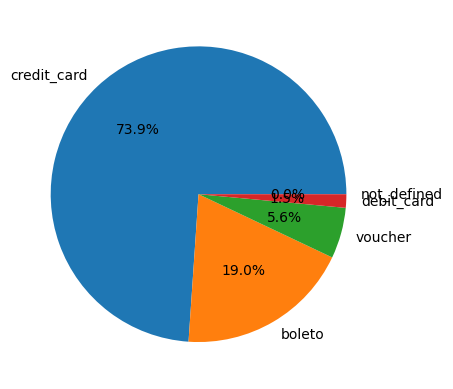

In [102]:
payment_method.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.show()

Phân tích đánh giá

In [103]:
reviews['review_score'].value_counts()

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

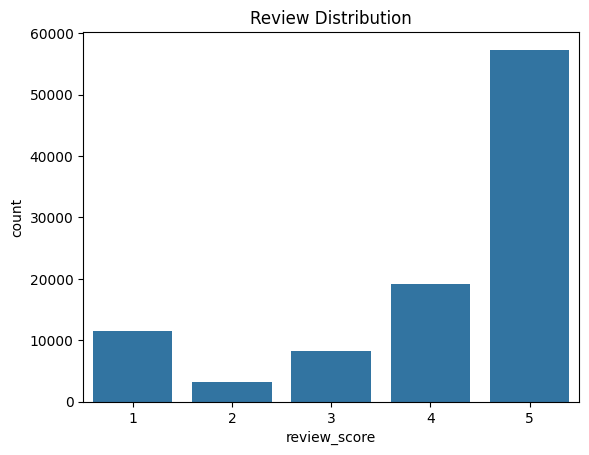

In [104]:
sns.countplot(
    x='review_score',
    data=reviews
)

plt.title(
    'Review Distribution'
)

plt.show()

Giá trị đơn hàng

In [105]:
order_value = (
    payments.groupby('order_id')
    ['payment_value']
    .sum()
)

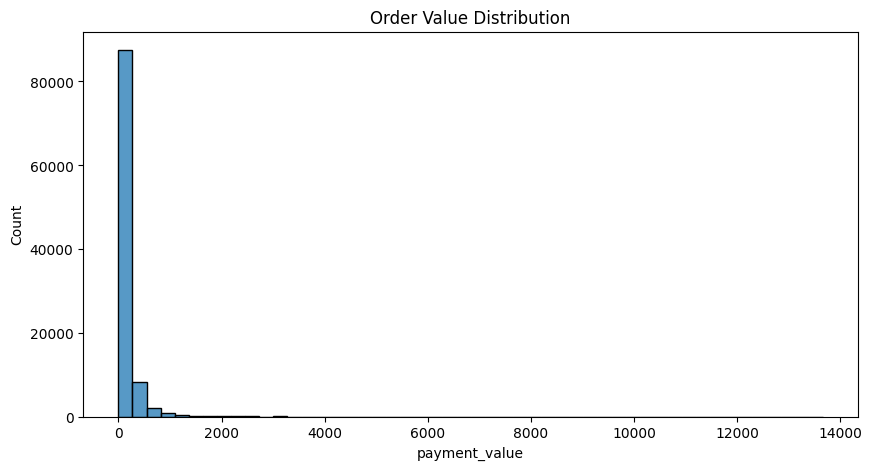

In [106]:
plt.figure(figsize=(10,5))

sns.histplot(
    order_value,
    bins=50
)

plt.title(
    'Order Value Distribution'
)

plt.show()

Thời gian giao hàng

In [107]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

In [108]:
orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    -
    orders['order_purchase_timestamp']
).dt.days

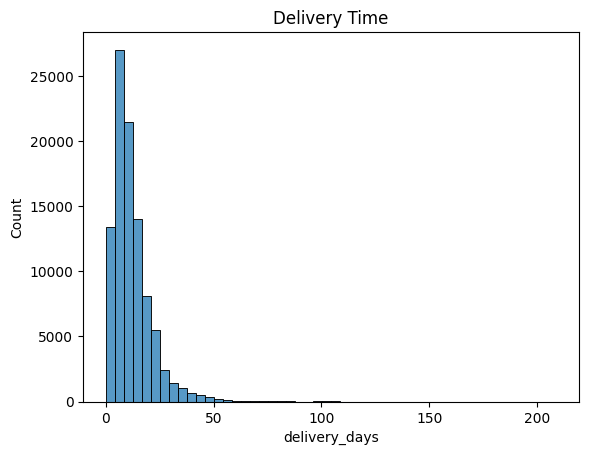

In [109]:
sns.histplot(
    orders['delivery_days'],
    bins=50
)

plt.title(
    'Delivery Time'
)

plt.show()

Heatmap tương quan

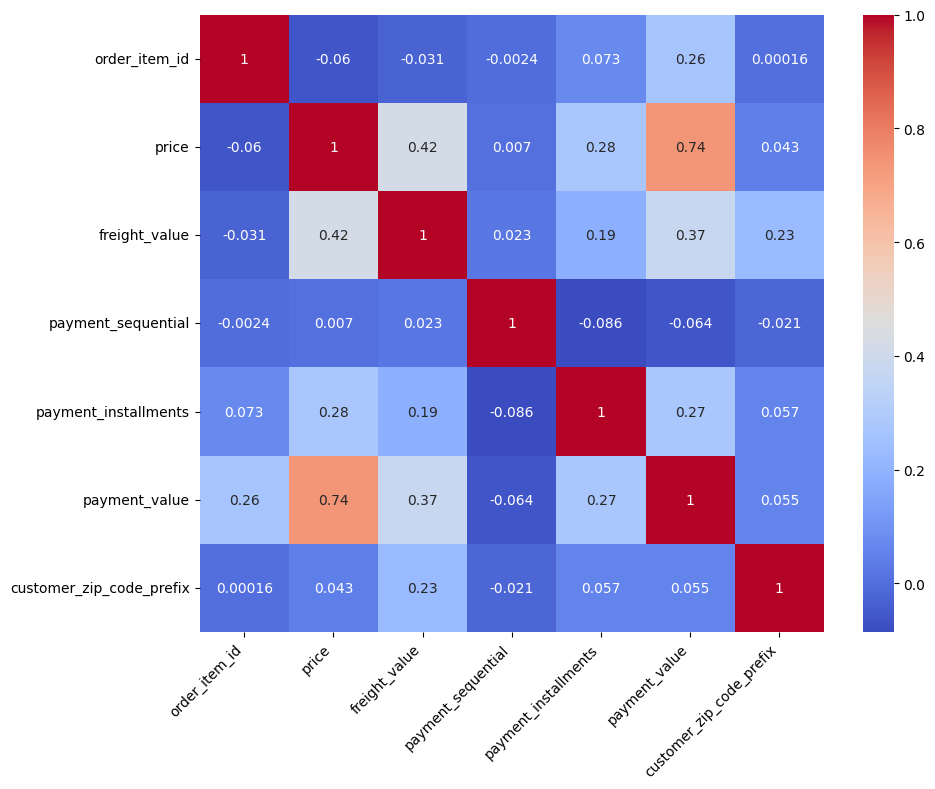

In [110]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()